# IBM watsonx.governance evaluation of Agentic App developed using Langgraph

This notebook demonstrates how to use the Agentic AI evaluators from IBM watsonx.governance for governing your applications right in your development environment.

The sample app shown here is an Agentic RAG example for querying information about IBM watsonx.governance capabilities. It makes use of OpenAI's `gpt-4o-mini` LLM for answer generation, and `text-embedding-3-small` embedding model for converting the queries to embeddings. 


### Install the dependencies

In [ ]:
%pip install --quiet "ibm-watsonx-gov[agentic,visualization]" "langchain-chroma<0.3.0"  "langchain-openai<=0.3.0" "langgraph>=0.2.23,<0.5.0"

**Note**: If you encounter any Torch-related attribute errors while setting up the evaluator, try resolving them by running the cell below to uninstall Torch. This step is required when running in Watson Studio.

In [ ]:
# %pip uninstall -y torch

### Runtime-specific Python library updates and rebuilds

#### For Runtime 24.1
If you are running the notebook in the Runtime 24.1 environment, uncomment the below cell. It force-reinstalls certain Python packages to ensure they are rebuilt or upgraded for compatibility with NumPy 2.x.

In [ ]:
# %pip install --upgrade --force-reinstall --no-cache-dir chromadb tensorflow transformers numexpr bottleneck opencv-python opentelemetry-exporter-otlp

#### For Runtime 25.1
If you are running the notebook in Runtime 25.1 environment, uncomment the below cells. The following cells installs `pysqlite3-binary` and configures it as the default `sqlite3`, overriding the older system-managed version. 

In [ ]:
# %pip install --upgrade --force-reinstall --no-cache-dir pysqlite3-binary

In [ ]:
# import sys
# import pysqlite3

# # replace stdlib sqlite3 with pysqlite3
# sys.modules["sqlite3"] = pysqlite3

### Accept the credentials

The following code snippet ensures that specific environment variables are set without being hardcoded in the script. It does so by prompting the user for input only if the variables are not already set.

The environment variables need to be set are:

1. **OPENAI_API_KEY:** This is required for Open AI capabilities.

For watsonx.governance Cloud
1. **WATSONX_APIKEY:** This is required for IBM watsonx.governance capabilities. Your Cloud API key can be generated by going to the [**Users** section of the Cloud console](https://cloud.ibm.com/iam#/users). From that page, click your name, scroll down to the **API Keys** section, and click **Create an IBM Cloud API key**. Give your key a name and click **Create**, then copy the created key and paste it below.
2. **WXG_SERVICE_INSTANCE_ID** [Optional] : Set if you have more than one watsonx.governance instance.
3. **WATSONX_REGION** [Optional]: Set if you are using IBM watsonx.governance as a service in a regional data center other than default **Dallas (us-south), in Texas US**. Supported region values are "us-south", "eu-de", "au-syd", "ca-tor", "jp-tok", "eu-gb".

For watsonx.governance OnPrem
1. **WATSONX_URL** : The CPD cluster URL.
2. **WATSONX_USERNAME** : The CPD username.
3. **WATSONX_PASSWORD** [Optional] : The CPD password.
4. **WATSONX_APIKEY** [Optional] : The CPD API key. Either WATSONX_APIKEY or WATSONX_PASSWORD is required for CPD authentication.
5. **WATSONX_VERSION** : The version of CPD.
6. **WATSONX_DISABLE_SSL** [Optional]: Set to true if you want to disable SSL.
7. **WXG_SERVICE_INSTANCE_ID** [Optional] : Set if you have more than one datamart

In [ ]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

# For watsonx.governance Cloud
_set_env("WATSONX_APIKEY")
#_set_env("WATSONX_REGION")
#_set_env("WXG_SERVICE_INSTANCE_ID")

# For watsonx.governance on-prem
# _set_env("WATSONX_URL")
# _set_env("WATSONX_USERNAME")
# _set_env("WATSONX_APIKEY")
# _set_env("WATSONX_PASSWORD") # Only one of apikey and password should be specified.
# _set_env("WATSONX_VERSION")
# _set_env("WATSONX_DISABLE_SSL")  # Set to true if you want to disable SSL
# _set_env("WXG_SERVICE_INSTANCE_ID") # To specify a governance instance id if more than one exist

OPENAI_API_KEY:  ········
WATSONX_APIKEY:  ········


### Set up the local vector store

We have created a local vector store comprising of a few medium posts by [Manish Bhide](https://medium.com/@manish.bhide) and [Ravi Chamarthy](https://medium.com/@ravi-chamarthy). These posts focus on the various capabilities in IBM watsonx.governance (and erstwhile IBM Watson OpenScale). Hence, our queries will focus on these capabilities covered in the above posts. 

For user's convenience, the vector store has been compressed. The following cell downloads the compressed file, extracts it locally, and initializes the Chroma store. 

In [2]:
%rm medium_db.zip
%rm -r medium_db/

!wget https://github.com/IBM/ibm-watsonx-gov/raw/refs/heads/samples/notebooks/data/agentic/medium_db.zip

--2025-07-03 13:26:05--  https://github.com/IBM/ibm-watsonx-gov/raw/refs/heads/samples/notebooks/data/agentic/medium_db.zip
Resolving github.com (github.com)... 20.207.73.82
Connecting to github.com (github.com)|20.207.73.82|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/IBM/ibm-watsonx-gov/refs/heads/samples/notebooks/data/agentic/medium_db.zip [following]
--2025-07-03 13:26:06--  https://raw.githubusercontent.com/IBM/ibm-watsonx-gov/refs/heads/samples/notebooks/data/agentic/medium_db.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1203223 (1.1M) [application/zip]
Saving to: ‘medium_db.zip’

medium_db.zip       100%[===================>]   1.15M  3.13MB/s    in 0.4s    

2025-07-03 13:26:

In [3]:
import zipfile

with zipfile.ZipFile("medium_db.zip", "r") as zip_ref:
    zip_ref.extractall(".")

In [4]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

openai_embed_model = OpenAIEmbeddings(model="text-embedding-3-small")

vector_store = Chroma(
    collection_name="medium_articles",
    embedding_function=openai_embed_model,
    persist_directory="./medium_db"
)

### Set up the State

The `ibm-watsonx-gov` library provides a pydantic based state class - `EvaluationState`. This provides various attributes for your use e.g. `input_text` is for storing the application input, `context` is for storing the context documents. For simple applications, developers can extend this class for their use. 

In [5]:
from ibm_watsonx_gov.entities.state import EvaluationState

class AppState(EvaluationState):
    pass

### Set up the evaluator

For evaluating your Agentic AI applications, you need to first instantiate the `AgenticEvaluator` class. This class defines a few evaluators to compute the different metrics.

We are going to use the following evaluators in this notebook:
1. `evaluate_context_relevance` : To compute context relevance metric of your content retrieval tool.
2. `evaluate_faithfulness`: To compute faithfulness metric of your answer generation tool. This metric does not require ground truth.
3. `evaluate_answer_similarity`: To compute answer similarity metric of your answer generation tool. This metric requires ground truth for computation.

You can specify the evaluators to be computed after the graph invocation by specifying flag `compute_real_time` set to False (eg: `evaluate_context_relevance(compute_real_time=False)`)

In [6]:
from ibm_watsonx_gov.evaluators.agentic_evaluator import AgenticEvaluator

evaluator = AgenticEvaluator()

Custom exporter logging initialized. App name: macbookpro_ipykernel_launcher
Traceloop exporting traces to a custom exporter

Metrics are disabled


### Build your langgraph application

In [7]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langgraph.config import RunnableConfig

#### Define content retrieval node

We are using a Similarity with Threshold Retrieval strategy. This will fetch the top 3 documents matching the query if the threshold score is more than 0.1

The `retrieval_node` tool defined below is decorated with IBM watsonx.governance evaluator `evaluate_context_relevance` tool to compute the context relevance metric. This node reads the user query from the `input_text` attribute from the application state and writes the result into the `context` attribute back to the application state.

In [ ]:
@evaluator.evaluate_context_relevance(compute_real_time=False)
def retrieval_node(state: AppState, config: RunnableConfig) -> dict:
    similarity_threshold_retriever = vector_store.as_retriever(search_type="similarity_score_threshold",
                                                               search_kwargs={"k": 3,
                                                                              "score_threshold": 0.1})
    context = similarity_threshold_retriever.invoke(state.input_text)
    return {
        "context": [doc.page_content for doc in context]
    }

#### Define answer generation tool

We are using `gpt-4o-mini` to generate an answer for our query.

The `generate_node` defined below is decorated with two evaluators `evaluate_faithfulness` and `evaluate_answer_similarity` for computing answer quality metrics. Like in the previous cell, this node reads the user query from the `input_text` attribute from the application state, the `context` attribute consists of the context chunks. After generating the answer, the node writes the result into the `generated_text` attribute back to the application state.

In [ ]:
@evaluator.evaluate_faithfulness(compute_real_time=False)
@evaluator.evaluate_answer_similarity(compute_real_time=False)
def generate_node(state: AppState, config: RunnableConfig) -> dict:
    generate_prompt = ChatPromptTemplate.from_template(
        "Answer the following question based on the given context:\n"
        "Context: {context}\n"
        "Question: {input_text}\n"
        "Answer:"
    )

    formatted_prompt = generate_prompt.invoke(
        {"input_text": state.input_text, "context": "\n".join(state.context)})
    llm = ChatOpenAI(model="gpt-4o-mini")
    result = llm.invoke(formatted_prompt)
    return {
        "generated_text": result.content
    }

#### Assemble your application

In [10]:
from langgraph.graph import START, END, StateGraph

graph = StateGraph(AppState)

# Add nodes
graph.add_node("Retrieval \nNode", retrieval_node)
graph.add_node("Generation \nNode", generate_node)

# Add edges
graph.add_edge(START, "Retrieval \nNode")
graph.add_edge("Retrieval \nNode", "Generation \nNode")
graph.add_edge("Generation \nNode", END)

# Compile the graph
rag_app = graph.compile()


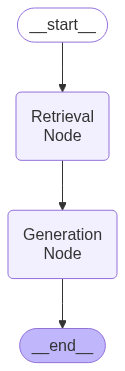

In [11]:
from langchain_core.runnables.graph import MermaidDrawMethod

image = rag_app.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)

from IPython.display import Image, display
display(Image(data=image))

### Do a single invocation

Now the application is invoked for a single row of data. You will see two new keys as the input:
1. `ground_truth`: As the name suggests, this attribute holds the ground truth for your input text. This is needed for the answer similarity metric, which is a reference based metric. For the other metrics, this is not required.
2. `interaction_id`: This is required so that IBM watsonx.governance can keep track of individual rows and associate metrics with each row. This will become evident when we do batch invocation in the next cell.

In [12]:
evaluator.start_run()
result = rag_app.invoke({"input_text": "What is concept drift?", "ground_truth": "Concept drift occurs when the statistical properties of the target variable change over time, causing a machine learning model’s predictions to become less accurate.", "interaction_id":"1"})
evaluator.end_run()

### Prepare the app results

In [13]:
import pandas as pd

eval_result = evaluator.get_result()
metric_result = eval_result.to_df()

### Display the metric results

In [ ]:
from IPython.display import display

display(metric_result)

#### Get Metric Results for a specific node

In [15]:
eval_result.get_aggregated_metrics_results(node_name="Generation \nNode")

[{'name': 'faithfulness',
  'method': 'sentence_bert_mini_lm',
  'provider': 'unitxt',
  'value': 0.3033757507801056,
  'group': 'answer_quality',
  'min': 0.3033757507801056,
  'max': 0.3033757507801056,
  'count': 1,
  'node_name': 'Generation \nNode',
  'applies_to': 'node',
  'individual_results': [{'name': 'faithfulness',
    'method': 'sentence_bert_mini_lm',
    'provider': 'unitxt',
    'value': 0.3033757507801056,
    'group': 'answer_quality',
    'thresholds': [{'type': 'lower_limit', 'value': 0.7}],
    'applies_to': 'node',
    'interaction_id': 'eb1167b367a9c3787c65c1e582e2e662',
    'conversation_id': 'eb1167b367a9c3787c65c1e582e2e662',
    'node_name': 'Generation \nNode',
    'execution_count': 1,
    'execution_order': 2}]},
 {'name': 'answer_similarity',
  'method': 'sentence_bert_mini_lm',
  'provider': 'unitxt',
  'value': 0.9129981398582458,
  'group': 'answer_quality',
  'min': 0.9129981398582458,
  'max': 0.9129981398582458,
  'count': 1,
  'node_name': 'Generat

### Invoke the graph on multiple rows

IBM watsonx.governance evaluation of Agentic Applications can be done with batch invocation too. Here, a dataframe with questions and ground truths for those questions have been defined. The dataframe index has been used as  `record_id` to uniquely identify each row. 

In [ ]:
import pandas as pd

question_bank_df = pd.read_csv("https://raw.githubusercontent.com/IBM/ibm-watsonx-gov/refs/heads/samples/notebooks/data/agentic/medium_question_bank.csv")
question_bank_df["interaction_id"] = question_bank_df.index.astype(str)
question_bank_df

### Display the metric results

In [ ]:
evaluator.start_run()
result = rag_app.batch(inputs=question_bank_df.to_dict("records"))
evaluator.end_run()

In [ ]:
eval_result = evaluator.get_result()
metric_result = eval_result.to_df()
display(metric_result)

### CHANGELOG

#### [0.0.4] - 2025-06-27
##### Added
- Changes related to the new agentic evaluator

#### [0.0.3] - 2025-03-28
##### Added
- Removed `transform_to_wide_format` method and use `display_table` to show metrics results in wide and sortable format
- Changed the graph image drawing to use pyppeteer+nest_asyncio

#### [0.0.2] - 2025-03-06
##### Added
- `transform_to_wide_format` method to show metrics results in wide format
- Better documentation in cells to explain various attributes of the state.

#### [0.0.1] - 2025-03-01
##### Added
- First set of evaluator nodes from IBM watsonx.governance



Developed by [Prem Piyush Goyal](https://www.linkedin.com/in/prempiyush/)